In [221]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Objective

Analyze customer purchasing behavior to identify recurring customer patterns and determine which behaviors can be translated into automated engagement rules.

## 1 - Exploratory Data Analysis

In [222]:
df = pd.read_csv('online_retail.csv')

In [223]:
df.shape

(541909, 8)

In [224]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [225]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [226]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 66.3 MB


In [227]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [228]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [229]:
df["Description"].fillna("No description")


0          WHITE HANGING HEART T-LIGHT HOLDER
1                         WHITE METAL LANTERN
2              CREAM CUPID HEARTS COAT HANGER
3         KNITTED UNION FLAG HOT WATER BOTTLE
4              RED WOOLLY HOTTIE WHITE HEART.
                         ...                 
541904            PACK OF 20 SPACEBOY NAPKINS
541905           CHILDREN'S APRON DOLLY GIRL 
541906          CHILDRENS CUTLERY DOLLY GIRL 
541907        CHILDRENS CUTLERY CIRCUS PARADE
541908          BAKING SET 9 PIECE RETROSPOT 
Name: Description, Length: 541909, dtype: str

In [230]:
total_number_of_customers = df["CustomerID"].nunique()

In [231]:
total_number_of_orders = df['InvoiceNo'].nunique()

In [232]:
average_number_of_orders_per_customer = total_number_of_orders / total_number_of_customers

In [233]:
median_number_of_orders_per_customer = df.groupby('CustomerID')['InvoiceNo'].nunique().median()

In [234]:
average_order_value = df['UnitPrice'].mean()

In [235]:
purchases_per_customer = df.groupby('CustomerID')['InvoiceNo'].nunique().sort_values()


## 2 - Visualize customer and revenue distributions

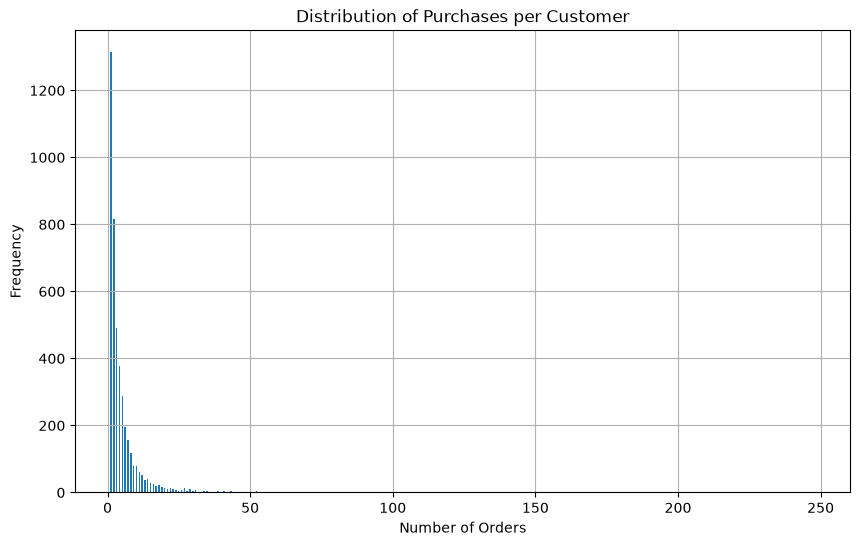

In [236]:
# graph distribution of purchases per customer

plt.figure(figsize=(10, 6))
df.groupby('CustomerID')['InvoiceNo'].nunique().hist(bins=500)
plt.xlabel('Number of Orders')      
plt.ylabel('Frequency')
plt.title('Distribution of Purchases per Customer')
plt.show()

there are a lot of customers that have only one purchase.
- what did they buy
- are they new
- are they a group of their own or are they in the same group as 2-5 purchases

In [237]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

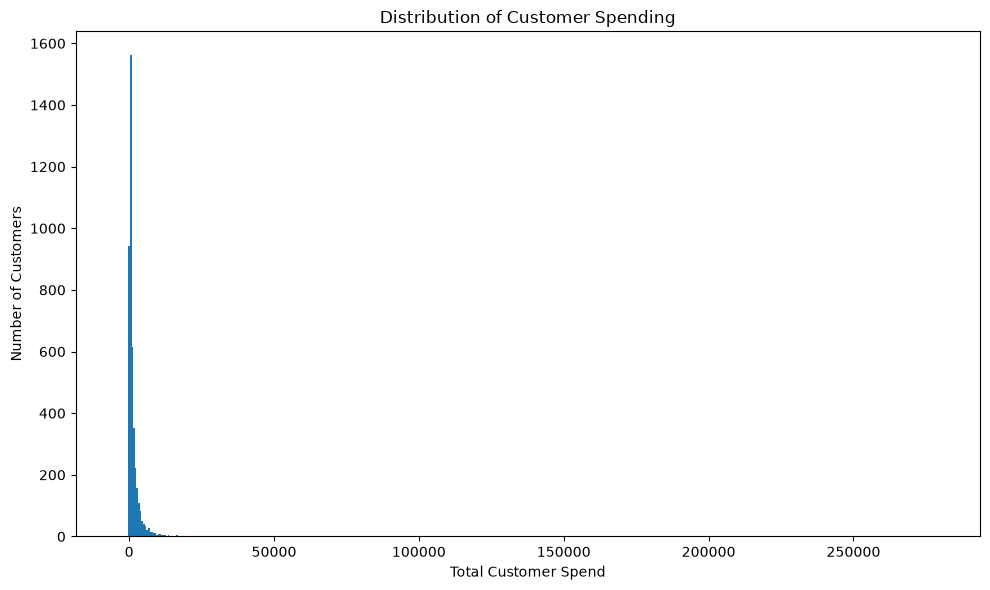

In [238]:
customer_spend = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
)

plt.figure(figsize=(10, 6))

plt.hist(
    customer_spend,
    bins=500
)

plt.title("Distribution of Customer Spending")
plt.xlabel("Total Customer Spend")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

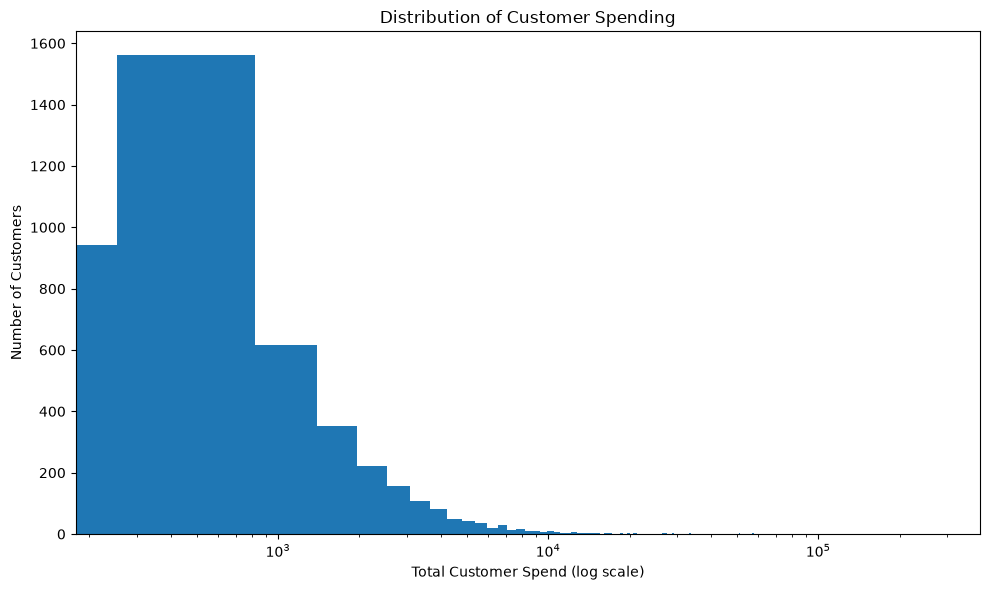

In [239]:
# retail spending is heavily skewed, using a log x-axis
plt.figure(figsize=(10, 6))

plt.hist(
    customer_spend,
    bins=500
)

plt.xscale("log")

plt.title("Distribution of Customer Spending")
plt.xlabel("Total Customer Spend (log scale)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

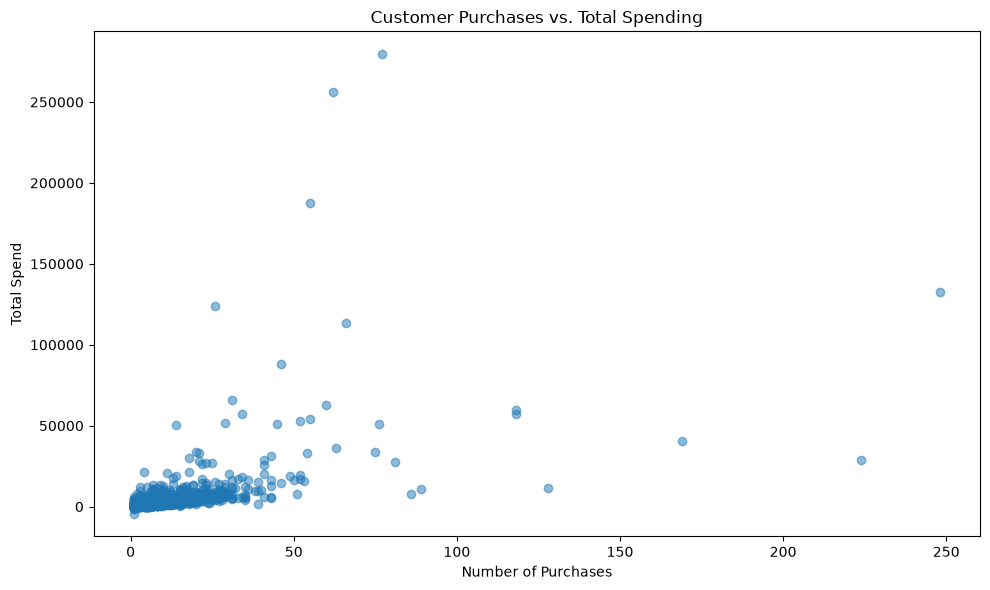

In [240]:
customer_summary = (
    df.groupby("CustomerID")
    .agg(
        Purchases=("InvoiceNo", "nunique"),
        Total_Spend=("Revenue", "sum")
    )
)

plt.figure(figsize=(10, 6))

plt.scatter(
    customer_summary["Purchases"],
    customer_summary["Total_Spend"],
    alpha=0.5
)

plt.title("Customer Purchases vs. Total Spending")
plt.xlabel("Number of Purchases")
plt.ylabel("Total Spend")

plt.tight_layout()
plt.show()

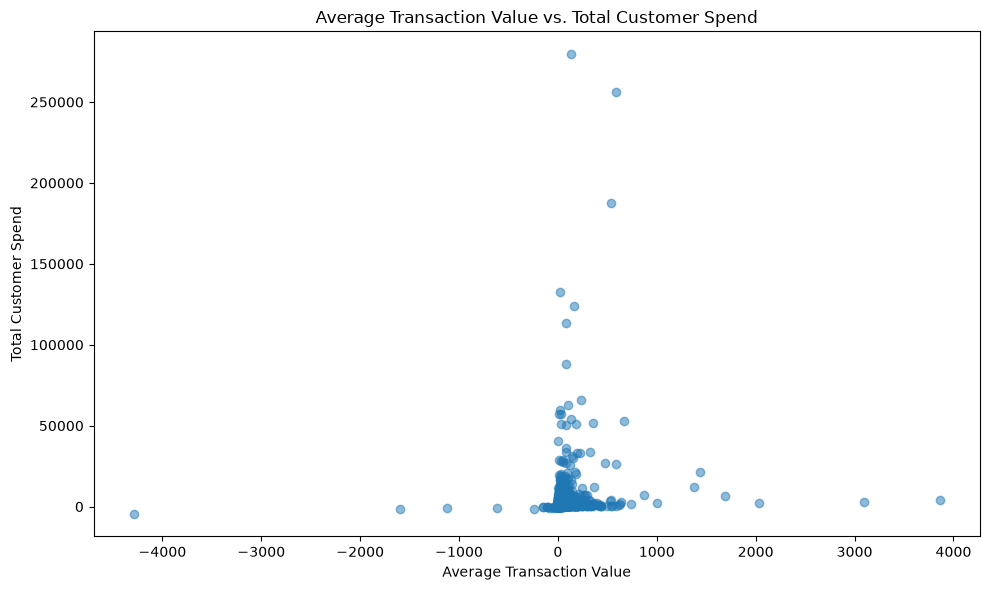

In [241]:
customer_summary = (
    df.groupby("CustomerID")
    .agg(
        Purchases=("InvoiceNo", "nunique"),
        Total_Spend=("Revenue", "sum"),
        Avg_Transaction=("Revenue", "mean")
    )
)

plt.figure(figsize=(10, 6))

plt.scatter(
    customer_summary["Avg_Transaction"],
    customer_summary["Total_Spend"],
    alpha=0.5
)

plt.title("Average Transaction Value vs. Total Customer Spend")
plt.xlabel("Average Transaction Value")
plt.ylabel("Total Customer Spend")

plt.tight_layout()
plt.show()

## 3 - Looking for behavioral dimensions

In [242]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

if not pd.api.types.is_string_dtype(df["CustomerID"]):
    df["CustomerID"] = df["CustomerID"].fillna(0).astype(int).astype(str)

/var/folders/53/vr8gs__x60sg207tybh25bv80000gn/T/ipykernel_12835/2789585944.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])


In [243]:
customer_summary = (
    df.groupby("CustomerID")
    .agg(
        Purchases=("InvoiceNo", "nunique"),
        Total_Spend=("Revenue", "sum"),
        Avg_Transaction=("Revenue", "mean")
    )
)

customer_summary.head(20)


,Purchases,Total_Spend,Avg_Transaction
CustomerID,,,
0,3710,1447682.12,10.717220
12346,2,0.00,0.000000
12347,7,4310.00,23.681319
12348,4,1797.24,57.975484
12349,1,1757.55,24.076027
12350,1,334.40,19.670588
12352,11,1545.41,16.267474
12353,1,89.00,22.250000
12354,1,1079.40,18.610345


In [244]:
# number of purchaches
# average days between paurchanes
# total spend
# average transcation value
# unique products
# unique product categories
# variateion in days between purchases


#### Group with no customer ID

In [245]:
no_id = df[df["CustomerID"] == "0"].copy()

no_id[
    [
        "InvoiceNo",
        "InvoiceDate",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "Revenue",
        "Country"
    ]
].head(2)

,InvoiceNo,InvoiceDate,StockCode,Description,Quantity,UnitPrice,Revenue,Country
622,536414,2010-12-01 11:52:00,22139,NaN,56,0.00,0.00,United Kingdom
1443,536544,2010-12-01 14:32:00,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2.51,2.51,United Kingdom


In [246]:
no_id[
    ["Quantity", "UnitPrice", "Revenue"]
].describe()

,Quantity,UnitPrice,Revenue
count,135080.000000,135080.000000,135080.000000
mean,1.995573,8.076577,10.717220
std,66.696153,151.900816,157.967893
min,-9600.000000,-11062.060000,-17836.460000
25%,1.000000,1.630000,2.460000
50%,1.000000,3.290000,4.960000
75%,3.000000,5.450000,10.790000
max,5568.000000,17836.460000,13541.330000


In [247]:
no_id["Revenue"].sum()

np.float64(1447682.12)

In [248]:
no_id["InvoiceDate"].agg(["min", "max"])

min   2010-12-01 11:52:00
max   2011-12-09 10:26:00
Name: InvoiceDate, dtype: datetime64[us]

In [249]:
no_ID_products = (
    no_id
    .groupby("Description")
    .agg(
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum"),
        Transactions=("InvoiceNo", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

no_ID_products.head(20)

,Units,Revenue,Transactions
Description,,,
DOTCOM POSTAGE,691,194339.12,693
REGENCY CAKESTAND 3 TIER,1478,31891.79,285
PARTY BUNTING,2995,30615.45,307
PAPER CHAIN KIT 50'S CHRISTMAS,3738,22291.46,180
CHARLOTTE BAG SUKI DESIGN,9177,22139.30,297
HOT WATER BOTTLE TEA AND SYMPATHY,1964,17407.37,130
RABBIT NIGHT LIGHT,3586,15618.79,193
RED RETROSPOT CHARLOTTE BAG,4962,11650.94,295
POPCORN HOLDER,5830,10871.16,171


In [250]:
no_id["Month"] = no_id["InvoiceDate"].dt.to_period("M")

no_id_monthly = (
    no_id
    .groupby("Month")
    .agg(
        Transactions=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
)

no_id_monthly

,Transactions,Units,Revenue
Month,,,
2010-12,317,45866,194353.00
2011-01,240,39587,84925.88
2011-02,191,15156,61516.50
2011-03,364,7860,103302.47
2011-04,360,10513,67159.27
2011-05,313,12539,75082.43
2011-06,305,-15299,83109.96
2011-07,334,27698,107061.63
2011-08,193,19587,66312.51


In [251]:

print("Earliest time:", no_id["InvoiceDate"].dt.time.min())
print("Latest time:", no_id["InvoiceDate"].dt.time.max())


Earliest time: 08:20:00
Latest time: 19:49:00


In [252]:
no_id["Hour"] = no_id["InvoiceDate"].dt.hour

hourly_volume = (
    no_id
    .groupby("Hour")
    .agg(
        Transactions=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
)

hourly_volume

,Transactions,Units,Revenue
Hour,,,
8,16,853,1737.59
9,202,33357,111619.22
10,348,-2490,178499.56
11,395,8578,92799.01
12,365,8242,25392.52
13,326,11655,54830.94
14,492,33980,146609.08
15,664,66300,290499.42
16,461,66703,281749.93


In [253]:
no_id["Day"] = no_id["InvoiceDate"].dt.day_name()


day_volume = (
    no_id
    .groupby("Day")
    .agg(
        Transactions=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
)


In [254]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_volume = day_volume.reindex(day_order)

day_volume

,Transactions,Units,Revenue
Day,,,
Monday,626.0,73668.0,314057.92
Tuesday,830.0,49055.0,402989.20
Wednesday,705.0,28983.0,203669.52
Thursday,682.0,49941.0,206410.81
Friday,828.0,63397.0,299294.63
Saturday,NaN,NaN,NaN
Sunday,39.0,4518.0,21260.04


In [256]:
day_dates = (
    no_id
    .assign(Day=no_id["InvoiceDate"].dt.day_name())
    .groupby("Day")["InvoiceDate"]
    .apply(lambda x: x.dt.date.nunique())
    .reindex(day_order, fill_value=0)
)

day_dates

Day
Monday       47
Tuesday      52
Wednesday    53
Thursday     53
Friday       50
Saturday      0
Sunday       22
Name: InvoiceDate, dtype: int64

In [257]:
day_volume["Transaction_Pct"] = (
    day_volume["Transactions"] /
    day_volume["Transactions"].sum() * 100
)

day_volume

,Transactions,Units,Revenue,Transaction_Pct
Day,,,,
Monday,626.0,73668.0,314057.92,16.873315
Tuesday,830.0,49055.0,402989.20,22.371968
Wednesday,705.0,28983.0,203669.52,19.002695
Thursday,682.0,49941.0,206410.81,18.382749
Friday,828.0,63397.0,299294.63,22.318059
Saturday,NaN,NaN,NaN,NaN
Sunday,39.0,4518.0,21260.04,1.051213


The no_id transactions appear to represent a distinct group within the dataset and may represent direct or end-user sales rather than purchases from identified reseller customers. This is a working hypothesis based on the purchasing patterns in the data, not something the dataset specifically identifies.

The no_id transactions occur mostly during the workweek, with sales recorded Monday through Friday and a smaller number on Sundays. Tuesday and Friday have the highest transaction volumes, but there isn't one day that stands out as dramatically busier than the others.

This is interesting because if these sales were primarily coming from something like a farmers market, makers market, pop-up event, or another periodic retail operation, I would expect to see much larger spikes on particular days. That pattern isn't really present in the data. Instead, the sales are spread across a number of weekdays, which makes a regular event-based sales channel less obvious.

The next step is to compare no_id and identified customers by revenue, units sold, product mix, transaction size, and timing. That should help determine whether these two groups are actually behaving like different types of sales channels.

#### Stock codes without descriptions

In [259]:
no_description = df[df["Description"].isna()].copy()

print("Rows with no description:", len(no_description))
print("Unique StockCodes:", no_description["StockCode"].nunique())

print("\nStockCodes:")
print(no_description["StockCode"].unique())

print("\nPrice range:")
print("Lowest price:", no_description["UnitPrice"].min())
print("Highest price:", no_description["UnitPrice"].max())

Rows with no description: 1454
Unique StockCodes: 960

StockCodes:
<ArrowStringArray>
[ '22139',  '21134',  '22145',  '37509', '85226A',  '85044',  '20950',
  '37461',  '84670',  '21777',
 ...
  '22947',  '22696',  '21758',  '21808',  '21803',  '22689',  '84581',
  '23406',  '21620',  '85175']
Length: 960, dtype: str

Price range:
Lowest price: 0.0
Highest price: 0.0


In [260]:
no_description = df[df["Description"].isna()].copy()

missing_description_summary = (
    no_description
    .groupby("StockCode")
    .agg(
        Rows=("StockCode", "size"),
        Transactions=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Customers=("CustomerID", "nunique"),
        Countries=("Country", "nunique")
    )
    .sort_values("Transactions", ascending=False)
)

missing_description_summary

,Rows,Transactions,Units,Customers,Countries
StockCode,,,,,
35965,10,10,38,1,1
23084,10,10,332,1,1
22084,9,9,-129,1,1
22451,6,6,-14,1,1
23348,5,5,794,1,1
...,...,...,...,...,...
22453,1,1,-12,1,1
22454,1,1,-20,1,1
22461,1,1,-36,1,1


In [261]:
invoice_item_counts = (
    df.groupby("InvoiceNo")["StockCode"]
    .nunique()
    .rename("Unique_Items")
)

no_description_orders = no_description.copy()

no_description_orders = no_description_orders.merge(
    invoice_item_counts,
    on="InvoiceNo",
    how="left"
)

no_description_orders["Order_Type"] = np.where(
    no_description_orders["Unique_Items"] == 1,
    "Stand-alone",
    "Multiple items"
)

In [262]:
order_type_summary = (
    no_description_orders
    .groupby(["StockCode", "Order_Type"])
    .agg(
        Orders=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum")
    )
    .reset_index()
)

order_type_summary

,StockCode,Order_Type,Orders,Units
0,10002,Stand-alone,2,177
1,10080,Stand-alone,1,170
2,10123C,Stand-alone,1,-18
3,10123G,Stand-alone,1,-38
4,10134,Stand-alone,1,-19
...,...,...,...,...
955,DCGS0074,Stand-alone,1,-1
956,DOT,Stand-alone,1,1000
957,POST,Stand-alone,4,3350
958,gift_0001_10,Stand-alone,1,30


In [263]:
no_description_orders["Customer_Type"] = np.where(
    no_description_orders["CustomerID"] == 0,
    "no_id",
    "Identified"
)

customer_type_summary = (
    no_description_orders
    .groupby(["StockCode", "Customer_Type"])
    .agg(
        Orders=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum")
    )
    .reset_index()
)

customer_type_summary

,StockCode,Customer_Type,Orders,Units
0,10002,Identified,2,177
1,10080,Identified,1,170
2,10123C,Identified,1,-18
3,10123G,Identified,1,-38
4,10134,Identified,1,-19
...,...,...,...,...
955,DCGS0074,Identified,1,-1
956,DOT,Identified,1,1000
957,POST,Identified,4,3350
958,gift_0001_10,Identified,1,30


In [264]:
alpha_stock_codes = (
    no_description.loc[
        no_description["StockCode"].str.contains(r"[A-Za-z]", na=False),
        "StockCode"
    ]
    .drop_duplicates()
    .sort_values()
)

alpha_stock_codes.tolist()

['10123C',
 '10123G',
 '15044B',
 '15058A',
 '15058B',
 '15060B',
 '16020C',
 '16151A',
 '16156S',
 '16162L',
 '16162M',
 '16169K',
 '16169P',
 '16202B',
 '16207A',
 '16207B',
 '16244B',
 '16248B',
 '17007B',
 '17011A',
 '17011F',
 '17012A',
 '17012B',
 '17013D',
 '17014A',
 '17090D',
 '17091A',
 '17165D',
 '18094C',
 '18097A',
 '18098C',
 '35001W',
 '35004C',
 '35004P',
 '35271S',
 '35591T',
 '35592T',
 '35597A',
 '35597D',
 '35598A',
 '35603B',
 '35607A',
 '35609A',
 '35809A',
 '35809B',
 '35810B',
 '35815P',
 '35818B',
 '35819B',
 '35819P',
 '35823P',
 '35824B',
 '35911A',
 '35915C',
 '35916A',
 '35916B',
 '35916C',
 '37379A',
 '37444A',
 '37444B',
 '37444C',
 '37477B',
 '37477C',
 '37477D',
 '37479B',
 '37489A',
 '40018F',
 '40046A',
 '44091A',
 '46037A',
 '46115B',
 '46126A',
 '46775D',
 '47013C',
 '47021G',
 '47341A',
 '47343A',
 '47344B',
 '47503A',
 '47504K',
 '47556B',
 '47559B',
 '47563B',
 '47570B',
 '47574B',
 '47591A',
 '47591B',
 '47591D',
 '47593A',
 '48173C',
 '62043B',

#### Looking into ALPHA codes

In [265]:
codes_to_check = [
    "C2",
    "DCGS0055",
    "DCGS0057",
    "DCGS0066P",
    "DCGS0070",
    "DCGS0071",
    "DCGS0072",
    "DCGS0074",
    "DOT",
    "POST",
    "gift_0001_10",
    "gift_0001_30"
]

code_details = (
    df[df["StockCode"].isin(codes_to_check)]
    .groupby("StockCode")
    .agg(
        Rows=("StockCode", "size"),
        Orders=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum"),
        Customers=("CustomerID", "nunique"),
        Avg_Price=("UnitPrice", "mean"),
        Min_Price=("UnitPrice", "min"),
        Max_Price=("UnitPrice", "max")
    )
    .sort_values("Orders", ascending=False)
)

code_details

,Rows,Orders,Units,Revenue,Customers,Avg_Price,Min_Price,Max_Price
StockCode,,,,,,,,
POST,1256,1254,6353,66230.64,380,36.933495,0.0,8142.75
DOT,710,710,1707,206245.48,2,290.495859,0.0,4505.17
C2,144,144,290,6986.00,30,49.291667,0.0,150.00
gift_0001_10,9,9,39,74.97,1,7.404444,0.0,8.33
gift_0001_30,8,8,37,175.53,1,21.941250,0.0,25.53
DCGS0070,2,2,-7,12.72,1,6.360000,0.0,12.72
DCGS0055,1,1,-1,0.00,1,0.000000,0.0,0.00
DCGS0057,1,1,-6,0.00,1,0.000000,0.0,0.00
DCGS0066P,1,1,-3,0.00,1,0.000000,0.0,0.00


In [266]:
customer_type = (
    df[df["StockCode"].isin(codes_to_check)]
    .assign(
        Customer_Type=lambda x: np.where(
            x["CustomerID"] == 0,
            "no_id",
            "Identified"
        )
    )
    .groupby(["StockCode", "Customer_Type"])
    .agg(
        Orders=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

customer_type

,StockCode,Customer_Type,Orders,Units,Revenue
0,C2,Identified,144,290,6986.00
1,DCGS0055,Identified,1,-1,0.00
2,DCGS0057,Identified,1,-6,0.00
3,DCGS0066P,Identified,1,-3,0.00
4,DCGS0070,Identified,2,-7,12.72
5,DCGS0071,Identified,1,-2,0.00
6,DCGS0072,Identified,1,-1,0.00
7,DCGS0074,Identified,1,-1,0.00
8,DOT,Identified,710,1707,206245.48
9,POST,Identified,1254,6353,66230.64


In [267]:
invoice_items = (
    df.groupby("InvoiceNo")["StockCode"]
    .nunique()
    .rename("Unique_Items")
)

code_orders = (
    df[df["StockCode"].isin(codes_to_check)]
    .merge(invoice_items, on="InvoiceNo")
    .assign(
        Order_Type=lambda x: np.where(
            x["Unique_Items"] == 1,
            "Stand-alone",
            "Multiple items"
        )
    )
    .groupby(["StockCode", "Order_Type"])
    .agg(
        Orders=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum")
    )
    .reset_index()
)

code_orders

,StockCode,Order_Type,Orders,Units
0,C2,Multiple items,140,137
1,C2,Stand-alone,4,153
2,DCGS0055,Stand-alone,1,-1
3,DCGS0057,Stand-alone,1,-6
4,DCGS0066P,Stand-alone,1,-3
5,DCGS0070,Multiple items,1,1
6,DCGS0070,Stand-alone,1,-8
7,DCGS0071,Stand-alone,1,-2
8,DCGS0072,Stand-alone,1,-1
9,DCGS0074,Stand-alone,1,-1


In [ ]:
pd.set_option("display.max_rows", None)

df[df["StockCode"].isin(codes_to_check)][
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "CustomerID",
        "Country",
        "InvoiceDate"
    ]
].sort_values(["StockCode", "InvoiceDate"])

In [268]:
codes_to_check = [
    "C2",
    "DCGS0055",
    "DCGS0057",
    "DCGS0066P",
    "DCGS0070",
    "DCGS0071",
    "DCGS0072",
    "DCGS0074"
]

df[df["StockCode"].isin(codes_to_check)][
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "CustomerID",
        "Country",
        "InvoiceDate"
    ]
].sort_values(["StockCode", "InvoiceDate"])

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,InvoiceDate
1423,536540,C2,CARRIAGE,1,50.00,14911,EIRE,2010-12-01 14:05:00
12119,537368,C2,CARRIAGE,1,50.00,14911,EIRE,2010-12-06 12:40:00
12452,537378,C2,CARRIAGE,1,50.00,14911,EIRE,2010-12-06 13:06:00
19975,537963,C2,CARRIAGE,1,50.00,13369,United Kingdom,2010-12-09 11:30:00
20016,538002,C2,CARRIAGE,1,50.00,14932,Channel Islands,2010-12-09 11:48:00
...,...,...,...,...,...,...,...,...
40052,539718,DCGS0070,CAMOUFLAGE DOG COLLAR,1,12.72,0,United Kingdom,2010-12-21 13:06:00
279253,561251,DCGS0070,NaN,-8,0.00,0,United Kingdom,2011-07-26 11:51:00
279252,561250,DCGS0071,NaN,-2,0.00,0,United Kingdom,2011-07-26 11:51:00
74838,542531,DCGS0072,NaN,-1,0.00,0,United Kingdom,2011-01-28 13:08:00
